---
**Pipeline:** [01 Dataset] → [02 Architecture] → **[03 Optimization]** → [04 Training] → [05 Evaluation] → [06 Export]

**Prev:** `02_model_architecture.ipynb` | **Next:** `04_model_training.ipynb`

---

# ⚡ 03 - Training Optimization

## Mixed Precision, Partial FC & Colab Optimizations

This notebook covers training optimizations for efficient face recognition.

**Contents:**
- 🚀 Mixed Precision Training (AMP)
- 🎯 Partial FC for memory efficiency
- 📈 Learning rate scheduling
- 💾 Colab checkpoint protection

---

## 1. Environment Setup

In [26]:
import os
import sys
from pathlib import Path

try:
    from google.colab import drive
    IN_COLAB = True
    print("🌐 Running in Google Colab")
    PROJECT_ROOT = Path("/content/face_recognition")
    drive.mount('/content/drive')
    DRIVE_ROOT = Path("/content/drive/MyDrive/face_based_attendance_system")
    print(f"⚡ Data: {PROJECT_ROOT}")
    print(f"💾 Models: {DRIVE_ROOT}")
except ImportError:
    IN_COLAB = False
    PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
    DRIVE_ROOT = None
    print("💻 Running locally")

sys.path.insert(0, str(PROJECT_ROOT))
print(f"📂 Project root: {PROJECT_ROOT}")

🌐 Running in Google Colab
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
⚡ Data: /content/face_recognition
💾 Models: /content/drive/MyDrive/face_based_attendance_system
📂 Project root: /content/face_recognition


In [27]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.amp import GradScaler, autocast
import math
import time

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🔧 Device: {device}")

if device.type == 'cuda':
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
    print(f"   Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")

🔧 Device: cuda
   GPU: Tesla T4
   Memory: 14.6 GB


## 2. Mixed Precision Training (AMP)

### Why Mixed Precision?

- **2x faster** training on Tensor Cores
- **50% less** GPU memory
- **No accuracy loss** with proper implementation

Uses FP16 for forward/backward pass, FP32 for weight updates.

In [28]:
# Simple AMP Example
class AMPTrainingExample:
    """Demonstrates mixed precision training."""

    def __init__(self, model, optimizer, use_amp=True):
        self.model = model
        self.optimizer = optimizer
        self.use_amp = use_amp and torch.cuda.is_available()
        self.scaler = GradScaler(enabled=self.use_amp)

    def train_step(self, images, labels):
        """
        Single training step with AMP.
        """
        self.optimizer.zero_grad()

        # Forward pass in mixed precision
        with autocast('cuda', enabled=self.use_amp):
            logits = self.model(images, labels)
            loss = F.cross_entropy(logits, labels)

        # Backward pass with gradient scaling
        self.scaler.scale(loss).backward()

        # Gradient clipping (prevents NaN)
        if self.use_amp:
            self.scaler.unscale_(self.optimizer)
        torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=5.0)

        # Update weights
        self.scaler.step(self.optimizer)
        self.scaler.update()

        return loss.item()

print("✅ AMP training example defined")

✅ AMP training example defined


In [29]:
# Benchmark AMP vs FP32
if torch.cuda.is_available():
    # Simple model for benchmarking
    model = nn.Sequential(
        nn.Conv2d(3, 64, 3, padding=1),
        nn.BatchNorm2d(64),
        nn.ReLU(),
        nn.Conv2d(64, 128, 3, padding=1),
        nn.BatchNorm2d(128),
        nn.ReLU(),
        nn.AdaptiveAvgPool2d(1),
        nn.Flatten(),
        nn.Linear(128, 512),
    ).cuda()

    x = torch.randn(32, 3, 112, 112).cuda()

    # Warmup
    for _ in range(10):
        _ = model(x)
    torch.cuda.synchronize()

    # FP32
    start = time.time()
    for _ in range(100):
        _ = model(x)
    torch.cuda.synchronize()
    fp32_time = time.time() - start

    # FP16 (AMP)
    start = time.time()
    for _ in range(100):
        with autocast('cuda'):
            _ = model(x)
    torch.cuda.synchronize()
    amp_time = time.time() - start

    print(f"📊 Forward Pass Benchmark (100 iterations):")
    print(f"   FP32: {fp32_time:.3f}s")
    print(f"   AMP:  {amp_time:.3f}s")
    print(f"   Speedup: {fp32_time/amp_time:.2f}x")
else:
    print("⚠️ CUDA not available, skipping benchmark")

📊 Forward Pass Benchmark (100 iterations):
   FP32: 1.949s
   AMP:  1.536s
   Speedup: 1.27x


## 3. Partial FC (Memory Efficient)

For large-scale face recognition (>100K classes), the FC layer becomes huge.

**Problem:** 512 embedding × 1M classes = 2GB for FC alone!

**Solution:** Sample subset of negative classes each batch.

In [30]:
class PartialFC(nn.Module):
    """
    Partial FC for memory-efficient training with many classes.

    Instead of computing full softmax over all classes,
    only use positive classes in batch + sampled negatives.
    """
    def __init__(self, in_features, num_classes, sample_rate=0.1, scale=64.0, margin=0.5):
        super().__init__()
        self.in_features = in_features
        self.num_classes = num_classes
        self.sample_rate = sample_rate
        self.scale = scale
        self.margin = margin

        # Class centers
        self.weight = nn.Parameter(torch.FloatTensor(num_classes, in_features))
        nn.init.xavier_uniform_(self.weight)

        self.cos_m = math.cos(margin)
        self.sin_m = math.sin(margin)

        print(f"✅ PartialFC initialized")
        print(f"   Classes: {num_classes:,}")
        print(f"   Sample rate: {sample_rate*100:.0f}%")
        print(f"   Memory per batch: ~{in_features * int(num_classes * sample_rate) * 4 / 1024**2:.1f} MB")

    def forward(self, embeddings, labels):
        # Get unique positive classes in batch
        pos_classes = torch.unique(labels)

        # Sample negative classes
        all_classes = set(range(self.num_classes))
        pos_set = set(pos_classes.cpu().numpy())
        neg_classes = list(all_classes - pos_set)

        num_neg = int(self.num_classes * self.sample_rate)
        if len(neg_classes) > num_neg:
            import random
            neg_classes = random.sample(neg_classes, num_neg)

        # Combine positive + negative classes
        sampled_classes = torch.cat([pos_classes, torch.tensor(neg_classes, device=labels.device)])

        # Get subset of weights
        sampled_weight = self.weight[sampled_classes]
        sampled_weight = F.normalize(sampled_weight, p=2, dim=1)

        # Compute cosine similarity
        cos_theta = F.linear(embeddings, sampled_weight)
        cos_theta = cos_theta.clamp(-1.0 + 1e-7, 1.0 - 1e-7)

        # Map labels to sampled indices
        class_to_idx = {c.item(): i for i, c in enumerate(sampled_classes)}
        mapped_labels = torch.tensor([class_to_idx[l.item()] for l in labels], device=labels.device)

        # Apply ArcFace margin
        sin_theta = torch.sqrt(1.0 - cos_theta ** 2)
        cos_theta_m = cos_theta * self.cos_m - sin_theta * self.sin_m

        one_hot = F.one_hot(mapped_labels, len(sampled_classes)).float()
        logits = torch.where(one_hot == 1, cos_theta_m, cos_theta)
        logits = logits * self.scale

        return logits, mapped_labels

# Test
pfc = PartialFC(512, 1000000, sample_rate=0.01)  # 1M classes, 1% sample

✅ PartialFC initialized
   Classes: 1,000,000
   Sample rate: 1%
   Memory per batch: ~19.5 MB


## 4. Learning Rate Scheduling

### Warmup + Cosine Decay

- **Warmup**: Gradually increase LR from 0 to base_lr
- **Cosine Decay**: Smoothly decrease LR following cosine curve

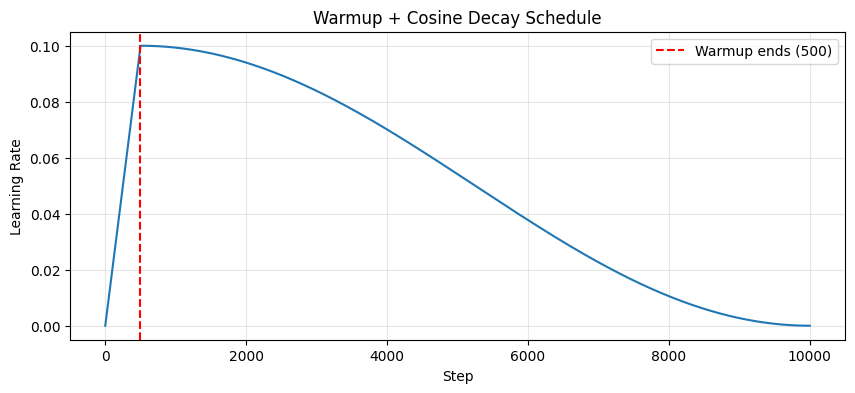

In [31]:
import matplotlib.pyplot as plt
import numpy as np

def get_warmup_cosine_schedule(total_steps, warmup_steps, base_lr, min_lr=1e-6):
    """
    Create warmup + cosine decay learning rate schedule.
    """
    lrs = []
    for step in range(total_steps):
        if step < warmup_steps:
            # Linear warmup
            lr = base_lr * step / warmup_steps
        else:
            # Cosine decay
            progress = (step - warmup_steps) / (total_steps - warmup_steps)
            lr = min_lr + 0.5 * (base_lr - min_lr) * (1 + math.cos(math.pi * progress))
        lrs.append(lr)
    return lrs

# Example schedule
total_steps = 10000
warmup_steps = 500
base_lr = 0.1

lrs = get_warmup_cosine_schedule(total_steps, warmup_steps, base_lr)

plt.figure(figsize=(10, 4))
plt.plot(lrs)
plt.axvline(warmup_steps, color='r', linestyle='--', label=f'Warmup ends ({warmup_steps})')
plt.xlabel('Step')
plt.ylabel('Learning Rate')
plt.title('Warmup + Cosine Decay Schedule')
plt.legend()
plt.grid(True, alpha=0.3)

# Create directory if it doesn't exist
(PROJECT_ROOT / 'docs' / 'screenshots').mkdir(parents=True, exist_ok=True)
plt.savefig(PROJECT_ROOT / 'docs' / 'screenshots' / 'lr_schedule.png', dpi=150)
plt.show()

In [32]:
class WarmupCosineScheduler:
    """
    Learning rate scheduler with warmup and cosine decay.
    """
    def __init__(self, optimizer, warmup_steps, total_steps, base_lr, min_lr=1e-6):
        self.optimizer = optimizer
        self.warmup_steps = warmup_steps
        self.total_steps = total_steps
        self.base_lr = base_lr
        self.min_lr = min_lr
        self.current_step = 0

    def step(self):
        self.current_step += 1
        lr = self.get_lr()
        for param_group in self.optimizer.param_groups:
            param_group['lr'] = lr
        return lr

    def get_lr(self):
        if self.current_step < self.warmup_steps:
            return self.base_lr * self.current_step / self.warmup_steps
        else:
            progress = (self.current_step - self.warmup_steps) / (self.total_steps - self.warmup_steps)
            return self.min_lr + 0.5 * (self.base_lr - self.min_lr) * (1 + math.cos(math.pi * progress))

    def state_dict(self):
        return {'current_step': self.current_step}

    def load_state_dict(self, state_dict):
        self.current_step = state_dict['current_step']

print("✅ WarmupCosineScheduler defined")

✅ WarmupCosineScheduler defined


## 5. Colab Checkpoint Protection

### The Problem
Colab can disconnect at any time, losing all training progress!

### The Solution
- Save checkpoints to Google Drive (persistent)
- Auto-resume from latest checkpoint
- Save every N steps (not just epochs)

In [33]:
from dataclasses import dataclass
from typing import Optional
import json

@dataclass
class CheckpointConfig:
    """Checkpoint configuration."""
    checkpoint_dir: Path
    save_every_n_steps: int = 500  # Frequent saves for Colab
    save_every_n_epochs: int = 1
    keep_last_n: int = 3  # Keep last N checkpoints
    save_to_drive: bool = True  # Save to Google Drive

class ColabCheckpointManager:
    """
    Checkpoint manager with Colab disconnect protection.
    """
    def __init__(self, config: CheckpointConfig):
        self.config = config
        config.checkpoint_dir.mkdir(parents=True, exist_ok=True)
        self.checkpoint_files = []

    def save(self, model, optimizer, scheduler, scaler, epoch, step, metrics):
        """
        Save checkpoint with all training state.
        """
        checkpoint = {
            'epoch': epoch,
            'step': step,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict() if scheduler else None,
            'scaler_state_dict': scaler.state_dict() if scaler else None,
            'metrics': metrics,
        }

        # Save checkpoint
        filename = f'checkpoint_epoch{epoch}_step{step}.pth'
        path = self.config.checkpoint_dir / filename
        torch.save(checkpoint, path)

        # Also save as 'latest'
        latest_path = self.config.checkpoint_dir / 'checkpoint_latest.pth'
        torch.save(checkpoint, latest_path)

        # Track and cleanup old checkpoints
        self.checkpoint_files.append(path)
        while len(self.checkpoint_files) > self.config.keep_last_n:
            old_path = self.checkpoint_files.pop(0)
            if old_path.exists():
                old_path.unlink()

        print(f"💾 Checkpoint saved: {filename}")
        return path

    def load_latest(self, model, optimizer=None, scheduler=None, scaler=None):
        """
        Load latest checkpoint for resume.
        """
        latest_path = self.config.checkpoint_dir / 'checkpoint_latest.pth'

        if not latest_path.exists():
            print("📭 No checkpoint found, starting fresh")
            return None

        print(f"📂 Loading checkpoint: {latest_path}")
        checkpoint = torch.load(latest_path, map_location='cpu')

        model.load_state_dict(checkpoint['model_state_dict'])

        if optimizer and checkpoint['optimizer_state_dict']:
            optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

        if scheduler and checkpoint['scheduler_state_dict']:
            scheduler.load_state_dict(checkpoint['scheduler_state_dict'])

        if scaler and checkpoint['scaler_state_dict']:
            scaler.load_state_dict(checkpoint['scaler_state_dict'])

        print(f"✅ Resumed from epoch {checkpoint['epoch']}, step {checkpoint['step']}")
        return checkpoint

print("✅ ColabCheckpointManager defined")

✅ ColabCheckpointManager defined


## 6. Complete Training Configuration

In [34]:
@dataclass
class TrainingConfig:
    """
    Complete training configuration.

    Optimized for:
    - Colab with T4/V100 GPU
    - 2-4 hour training time
    - Auto-resume on disconnect
    """
    # Model
    embedding_dim: int = 512
    num_classes: int = 9131  # VGGFace2

    # ArcFace
    arcface_scale: float = 64.0
    arcface_margin: float = 0.5

    # Training
    batch_size: int = 128
    num_epochs: int = 20
    base_lr: float = 0.1
    weight_decay: float = 5e-4
    momentum: float = 0.9

    # LR Schedule
    warmup_epochs: float = 1.0
    min_lr: float = 1e-6

    # Mixed Precision
    use_amp: bool = True
    grad_clip: float = 5.0

    # Checkpointing
    checkpoint_every_n_steps: int = 500
    keep_last_n_checkpoints: int = 3

    # Data
    num_workers: int = 4
    pin_memory: bool = True

    def to_dict(self):
        return {k: v for k, v in self.__dict__.items()}

# Default config
config = TrainingConfig()
print("📋 Training Configuration:")
print("="*50)
for k, v in config.to_dict().items():
    print(f"  {k}: {v}")

📋 Training Configuration:
  embedding_dim: 512
  num_classes: 9131
  arcface_scale: 64.0
  arcface_margin: 0.5
  batch_size: 128
  num_epochs: 20
  base_lr: 0.1
  weight_decay: 0.0005
  momentum: 0.9
  warmup_epochs: 1.0
  min_lr: 1e-06
  use_amp: True
  grad_clip: 5.0
  checkpoint_every_n_steps: 500
  keep_last_n_checkpoints: 3
  num_workers: 4
  pin_memory: True


## 7. Summary & Next Steps

In [35]:
print(f"""
📋 Training Optimizations Summary:
{"="*50}

1. Mixed Precision (AMP):
   - 2x faster training
   - 50% less memory
   - Use GradScaler for stability

2. Partial FC:
   - For large-scale (>100K classes)
   - Samples negative classes
   - Reduces memory significantly

3. Learning Rate Schedule:
   - Warmup: 1 epoch
   - Base LR: 0.1
   - Cosine decay to 1e-6

4. Colab Protection:
   - Checkpoint every 500 steps
   - Save to Google Drive
   - Auto-resume on restart

{"="*50}

📋 Next Steps:
  1. Run 05_model_training.ipynb for actual training
  2. Run 06_model_evaluation.ipynb for benchmarks
  3. Run 07_model_export.ipynb for deployment
""")


📋 Training Optimizations Summary:

1. Mixed Precision (AMP):
   - 2x faster training
   - 50% less memory
   - Use GradScaler for stability

2. Partial FC:
   - For large-scale (>100K classes)
   - Samples negative classes
   - Reduces memory significantly

3. Learning Rate Schedule:
   - Warmup: 1 epoch
   - Base LR: 0.1
   - Cosine decay to 1e-6

4. Colab Protection:
   - Checkpoint every 500 steps
   - Save to Google Drive
   - Auto-resume on restart


📋 Next Steps:
  1. Run 05_model_training.ipynb for actual training
  2. Run 06_model_evaluation.ipynb for benchmarks
  3. Run 07_model_export.ipynb for deployment

